# Torneo Inter-Grupal Connect-4
**Round-robin:** Hydra (Lacouture) · Minimax (Sanchez) · MCTSSoler (Soler)  
50 juegos por enfrentamiento · 3 matchups · 150 juegos totales

---

In [1]:
import json, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import defaultdict

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
})

with open('versus/roundrobin_results.json', encoding='utf-8') as f:
    data = json.load(f)

AGENTS = ['Hydra', 'Minimax', 'MCTSSoler']
COLORS = {'Hydra': '#e74c3c', 'Minimax': '#2980b9', 'MCTSSoler': '#27ae60'}
LIGHT  = {'Hydra': '#f1948a', 'Minimax': '#85c1e9', 'MCTSSoler': '#82e0aa'}

print(f"Datos cargados: {len(data['matchups'])} matchups")
for m in data['matchups']:
    s = m['summary']
    a, b = m['player_a'], m['player_b']
    total = s[a+'_wins'] + s[b+'_wins'] + s['draws']
    print(f"  {a:12} vs {b:12}: {s[a+'_wins']:2}W - {s[b+'_wins']:2}W - {s['draws']}D  ({total} juegos)")

Datos cargados: 3 matchups
  Hydra        vs Minimax     : 15W - 30W - 5D  (50 juegos)
  Hydra        vs MCTSSoler   : 32W - 14W - 4D  (50 juegos)
  Minimax      vs MCTSSoler   : 37W - 10W - 3D  (50 juegos)


---
## 1. Tabla de puntos (chess-style: Victoria=1 · Empate=0.5 · Derrota=0)

In [2]:
wins = defaultdict(int)
losses = defaultdict(int)
draws_count = defaultdict(int)
gp = defaultdict(int)

for m in data['matchups']:
    a, b = m['player_a'], m['player_b']
    s = m['summary']
    wa, wb, d = s[a+'_wins'], s[b+'_wins'], s['draws']
    wins[a] += wa;   wins[b] += wb
    losses[a] += wb; losses[b] += wa
    draws_count[a] += d; draws_count[b] += d
    gp[a] += wa+wb+d; gp[b] += wa+wb+d

pts     = {ag: wins[ag] + 0.5*draws_count[ag] for ag in AGENTS}
win_pct = {ag: wins[ag]/gp[ag] for ag in AGENTS}

print(f"{'':3} {'Agente':12} {'V':>4} {'D':>4} {'E':>4} {'PJ':>4} {'Pts':>6} {'Win%':>7}")
print('-' * 50)
for i, ag in enumerate(sorted(AGENTS, key=lambda x: -pts[x]), 1):
    print(f"{i:>3}. {ag:12} {wins[ag]:>4} {losses[ag]:>4} {draws_count[ag]:>4} {gp[ag]:>4} {pts[ag]:>6.1f} {win_pct[ag]:>6.1%}")

    Agente          V    D    E   PJ    Pts    Win%
--------------------------------------------------
  1. Minimax        67   25    8  100   71.0  67.0%
  2. Hydra          47   44    9  100   51.5  47.0%
  3. MCTSSoler      24   69    7  100   27.5  24.0%


---
## 2. Matriz Head-to-Head

                        Hydra        Minimax      MCTSSoler
------------------------------------------------------------
Hydra                     ---       15W / 5D       32W / 4D
Minimax              30W / 5D            ---       37W / 3D
MCTSSoler            14W / 4D       10W / 3D            ---

(Fila = resultados del agente fila contra el agente columna)


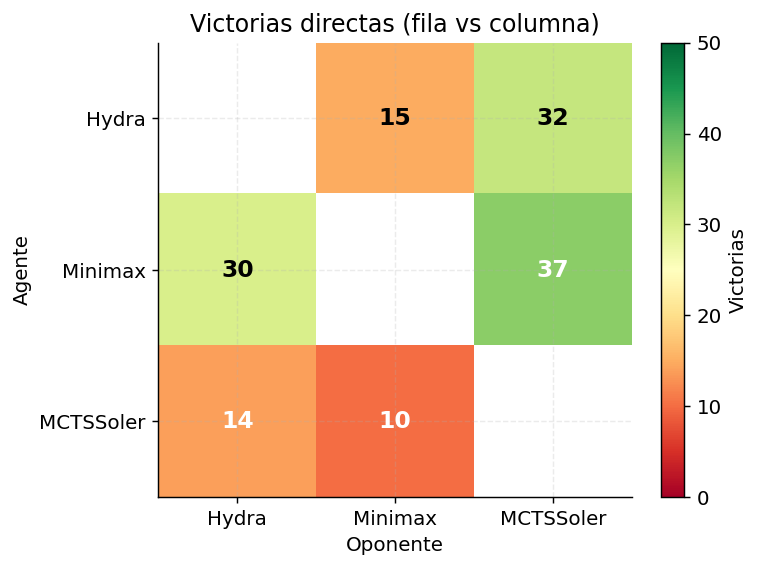

In [3]:
h2h = {a: {b: {'w': 0, 'd': 0} for b in AGENTS} for a in AGENTS}

for m in data['matchups']:
    a, b = m['player_a'], m['player_b']
    s = m['summary']
    h2h[a][b]['w'] = s[a+'_wins']; h2h[a][b]['d'] = s['draws']
    h2h[b][a]['w'] = s[b+'_wins']; h2h[b][a]['d'] = s['draws']

# Table
print(f"{'':14}", end='')
for b in AGENTS:
    print(f"{b:>15}", end='')
print()
print('-' * 60)
for a in AGENTS:
    print(f"{a:14}", end='')
    for b in AGENTS:
        if a == b:
            print(f"{'---':>15}", end='')
        else:
            cell = f"{h2h[a][b]['w']}W / {h2h[a][b]['d']}D"
            print(f"{cell:>15}", end='')
    print()
print("\n(Fila = resultados del agente fila contra el agente columna)")

# Heatmap
fig, ax = plt.subplots(figsize=(6, 4.5))
matrix = np.array([[h2h[a][b]['w'] if a != b else np.nan for b in AGENTS] for a in AGENTS], dtype=float)
im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=50, aspect='auto')
plt.colorbar(im, ax=ax, label='Victorias')
ax.set_xticks(range(len(AGENTS))); ax.set_yticks(range(len(AGENTS)))
ax.set_xticklabels(AGENTS); ax.set_yticklabels(AGENTS)
ax.set_xlabel('Oponente'); ax.set_ylabel('Agente')
ax.set_title('Victorias directas (fila vs columna)')
for i, a in enumerate(AGENTS):
    for j, b in enumerate(AGENTS):
        if a != b:
            v = h2h[a][b]['w']
            ax.text(j, i, str(v), ha='center', va='center', fontsize=13, fontweight='bold',
                    color='white' if v > 35 or v < 15 else 'black')
plt.tight_layout()
plt.savefig('versus/h2h_heatmap.png', bbox_inches='tight')
plt.show()

---
## 3. Elo Rating — el ranking que pondera calidad de victorias

El sistema **Elo** asigna un rating a cada jugador que sube o baja según el resultado esperado.  
La fórmula de actualización es:

$$R'_A = R_A + K\,(S_A - E_A)$$

donde $E_A = \dfrac{1}{1+10^{(R_B-R_A)/400}}$ es la probabilidad esperada de victoria, $S_A \in \{0, 0.5, 1\}$ el resultado real, y $K=32$ el factor de sensibilidad.  
**Clave:** ganarle a un rival con Elo alto da muchos puntos; ganarle a uno débil, pocos. Esto corrige el sesgo de "inflar victorias contra el rival más débil".

In [4]:
K = 32
elo = {ag: 1500.0 for ag in AGENTS}
elo_history = {ag: [1500.0] for ag in AGENTS}

def expected_score(ra, rb):
    return 1 / (1 + 10**((rb - ra) / 400))

game_counter = 0
matchup_breaks = []
matchup_labels = []

for m_idx, m in enumerate(data['matchups']):
    a, b = m['player_a'], m['player_b']
    matchup_breaks.append(game_counter)
    matchup_labels.append(f"{a} vs {b}")
    for g in m['games']:
        winner = g['winner']
        sa = 1.0 if winner == a else (0.0 if winner == b else 0.5)
        sb = 1.0 - sa
        ea = expected_score(elo[a], elo[b])
        eb = expected_score(elo[b], elo[a])
        elo[a] += K * (sa - ea)
        elo[b] += K * (sb - eb)
        for ag in AGENTS:
            elo_history[ag].append(elo[ag])
        game_counter += 1

print("Elo final (inicio = 1500):")
for ag in sorted(AGENTS, key=lambda x: -elo[x]):
    delta = elo[ag] - 1500
    sign = '+' if delta >= 0 else ''
    print(f"  {ag:12}  {elo[ag]:7.1f}  ({sign}{delta:.1f})")

Elo final (inicio = 1500):
  Minimax        1586.2  (+86.2)
  Hydra          1563.1  (+63.1)
  MCTSSoler      1350.7  (-149.3)


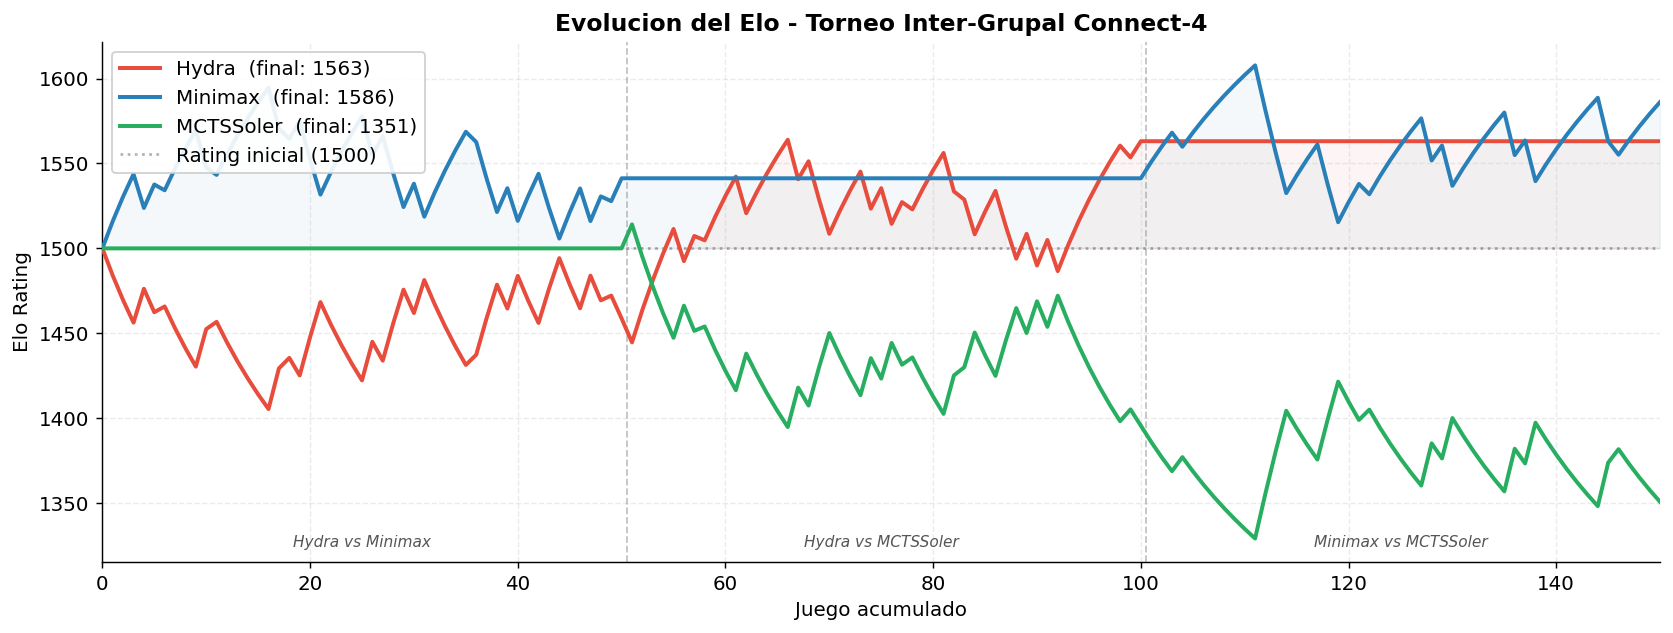

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

x = range(len(elo_history['Hydra']))
for ag in AGENTS:
    ax.plot(x, elo_history[ag], color=COLORS[ag], linewidth=2.2,
            label=f"{ag}  (final: {elo[ag]:.0f})", zorder=3)

# Matchup separators
for i, (brk, lbl) in enumerate(zip(matchup_breaks, matchup_labels)):
    ax.axvline(brk + 0.5 if brk > 0 else 0, color='#7f8c8d', linestyle='--', alpha=0.5, linewidth=1)
    mid = brk + 25
    ymin = ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else min(min(v) for v in elo_history.values()) - 10
    ax.text(mid, min(min(v) for v in elo_history.values()) - 5, lbl,
            ha='center', fontsize=8.5, color='#555', style='italic')

ax.axhline(1500, color='black', linestyle=':', alpha=0.3, label='Rating inicial (1500)')
ax.fill_between(x, 1500, elo_history['Hydra'],
                where=[v >= 1500 for v in elo_history['Hydra']],
                alpha=0.05, color=COLORS['Hydra'])
ax.fill_between(x, 1500, elo_history['Minimax'],
                where=[v >= 1500 for v in elo_history['Minimax']],
                alpha=0.05, color=COLORS['Minimax'])

ax.set_xlabel('Juego acumulado')
ax.set_ylabel('Elo Rating')
ax.set_title('Evolucion del Elo - Torneo Inter-Grupal Connect-4', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)
ax.set_xlim(0, game_counter)
plt.tight_layout()
plt.savefig('versus/elo_curve.png', bbox_inches='tight')
plt.show()

---
## 4. Ranking consolidado — tres metricas, un veredicto

    Agente       |     Pts   R |      Elo   R |   Win%   R |  Rank Avg
-----------------------------------------------------------------
  1. Minimax      |    71.0   1 |   1586.2   1 | 67.0%   1 |      1.00
  2. Hydra        |    51.5   2 |   1563.1   2 | 47.0%   2 |      2.00
  3. MCTSSoler    |    27.5   3 |   1350.7   3 | 24.0%   3 |      3.00


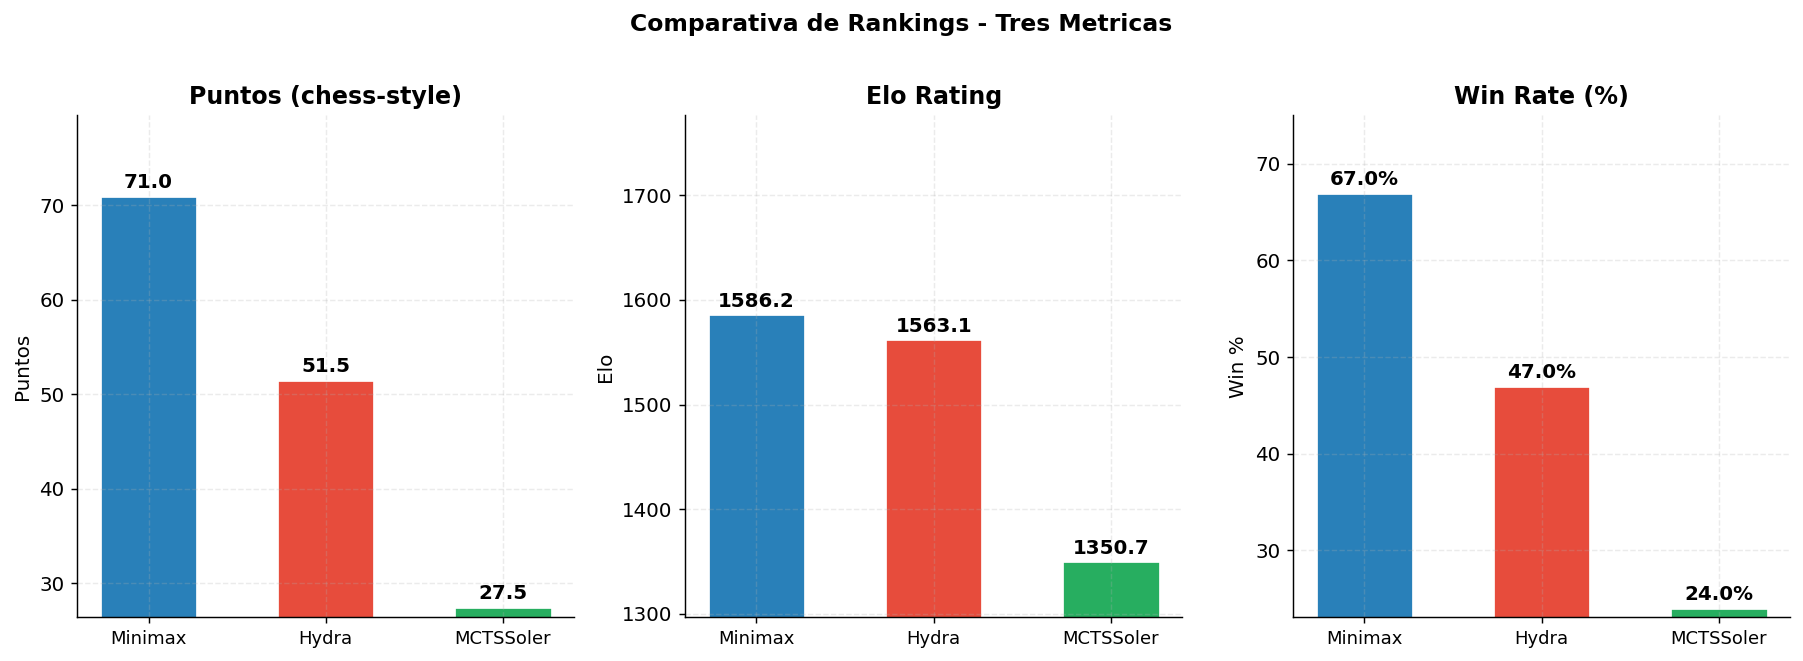

In [6]:
by_pts = sorted(AGENTS, key=lambda x: -pts[x])
by_elo = sorted(AGENTS, key=lambda x: -elo[x])
by_wr  = sorted(AGENTS, key=lambda x: -win_pct[x])

rank_pts = {ag: i+1 for i, ag in enumerate(by_pts)}
rank_elo = {ag: i+1 for i, ag in enumerate(by_elo)}
rank_wr  = {ag: i+1 for i, ag in enumerate(by_wr)}
avg_rank = {ag: (rank_pts[ag] + rank_elo[ag] + rank_wr[ag]) / 3 for ag in AGENTS}

print(f"{'':3} {'Agente':12} | {'Pts':>7} {'R':>3} | {'Elo':>8} {'R':>3} | {'Win%':>6} {'R':>3} | {'Rank Avg':>9}")
print('-' * 65)
for i, ag in enumerate(sorted(AGENTS, key=lambda x: avg_rank[x]), 1):
    print(f"{i:>3}. {ag:12} | {pts[ag]:>7.1f} {rank_pts[ag]:>3} | "
          f"{elo[ag]:>8.1f} {rank_elo[ag]:>3} | {win_pct[ag]:>5.1%} {rank_wr[ag]:>3} | {avg_rank[ag]:>9.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_data = [
    ('Puntos (chess-style)', pts, 'Puntos', False),
    ('Elo Rating', elo, 'Elo', False),
    ('Win Rate (%)', {ag: win_pct[ag]*100 for ag in AGENTS}, 'Win %', True),
]
for ax, (title, vals, ylabel, pct) in zip(axes, metrics_data):
    ags = sorted(AGENTS, key=lambda x: -vals[x])
    bar_colors = [COLORS[ag] for ag in ags]
    bars = ax.bar(ags, [vals[ag] for ag in ags], color=bar_colors,
                  edgecolor='white', linewidth=1.5, width=0.55)
    base = min(vals.values()) * 0.96
    ax.set_ylim(base, max(vals.values()) * 1.12)
    for bar, ag in zip(bars, ags):
        v = vals[ag]
        label = f"{v:.1f}%" if pct else f"{v:.1f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(vals.values())-base)*0.01,
                label, ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelsize=10)

plt.suptitle('Comparativa de Rankings - Tres Metricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('versus/ranking_comparativo.png', bbox_inches='tight')
plt.show()

---
## 5. Ventaja del primer jugador — por agente

En Connect-4 el jugador que mueve primero (ficha roja, representado como **-1** internamente) tiene ventaja teórica si ambos juegan perfectamente. Aqui medimos si cada agente aprovecha esa ventaja o si sus victorias dependen del orden de turno.

In [7]:
# Per-agent stats: as first mover (-1) vs second mover (+1)
fp_stats = {ag: {'fw': 0, 'fl': 0, 'fd': 0, 'sw': 0, 'sl': 0, 'sd': 0} for ag in AGENTS}

for m in data['matchups']:
    a, b = m['player_a'], m['player_b']
    for g in m['games']:
        first_ag  = g['first_player']           # plays as -1
        second_ag = b if first_ag == a else a   # plays as +1
        winner = g['winner']

        if winner is None:   # draw
            fp_stats[first_ag]['fd'] += 1
            fp_stats[second_ag]['sd'] += 1
        elif winner == first_ag:
            fp_stats[first_ag]['fw'] += 1
            fp_stats[second_ag]['sl'] += 1
        else:
            fp_stats[first_ag]['fl'] += 1
            fp_stats[second_ag]['sw'] += 1

print(f"{'Agente':12}  {'Como 1ro (-1)':>26}  {'Como 2do (+1)':>26}")
print(f"{'':12}  {'W':>4} {'L':>4} {'D':>4} {'WR%':>8}  {'W':>4} {'L':>4} {'D':>4} {'WR%':>8}")
print('-' * 64)
for ag in AGENTS:
    s = fp_stats[ag]
    n1 = s['fw']+s['fl']+s['fd']
    n2 = s['sw']+s['sl']+s['sd']
    wr1 = s['fw']/n1 if n1 else 0
    wr2 = s['sw']/n2 if n2 else 0
    print(f"{ag:12}  {s['fw']:>4} {s['fl']:>4} {s['fd']:>4} {wr1:>7.1%}  "
          f"{s['sw']:>4} {s['sl']:>4} {s['sd']:>4} {wr2:>7.1%}")

Agente                     Como 1ro (-1)               Como 2do (+1)
                 W    L    D      WR%     W    L    D      WR%
----------------------------------------------------------------
Hydra           26   20    4   52.0%    21   24    5   42.0%
Minimax         36   11    3   72.0%    31   14    5   62.0%
MCTSSoler       17   28    5   34.0%     7   41    2   14.0%


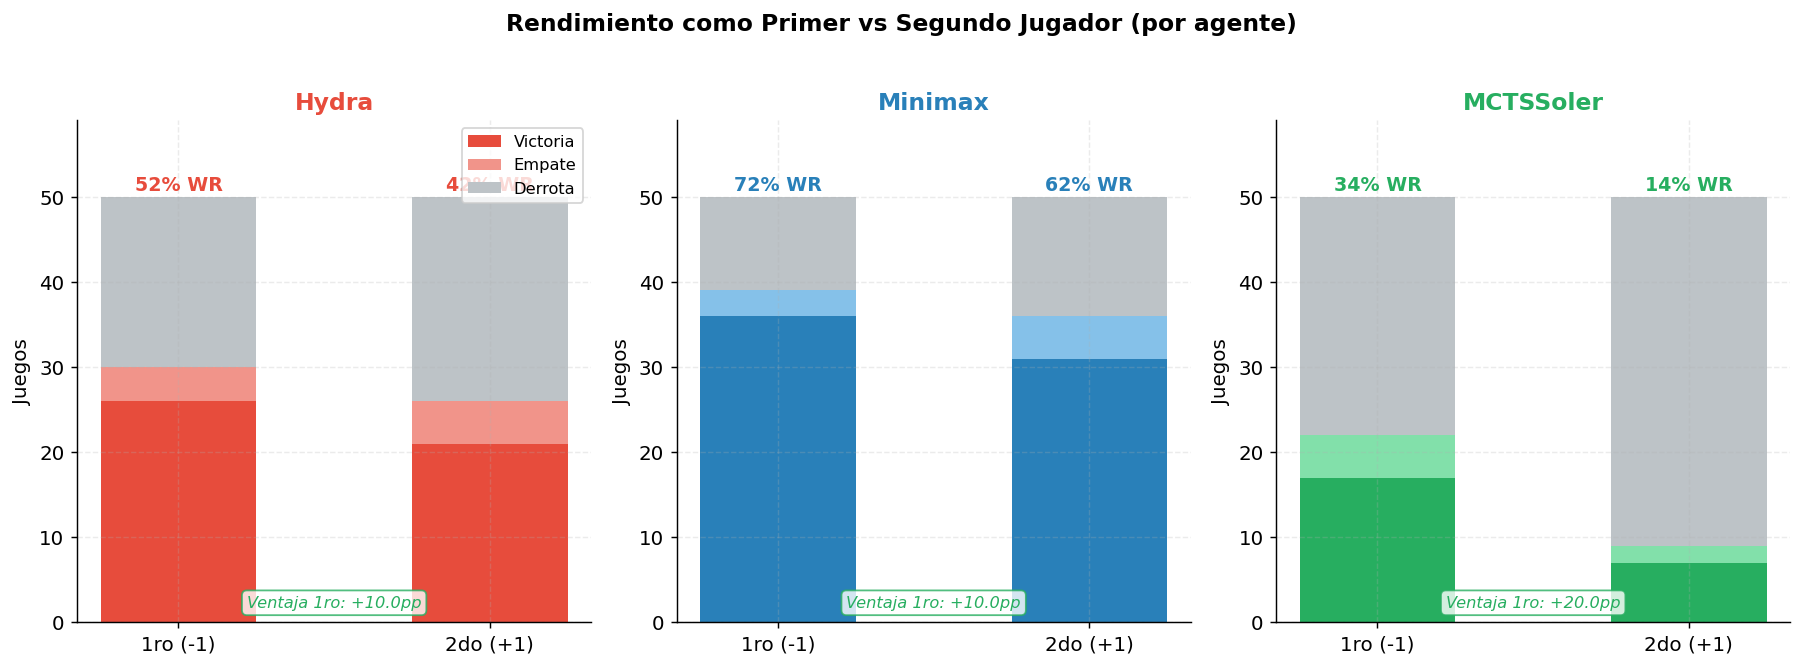

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, ag in zip(axes, AGENTS):
    s = fp_stats[ag]
    n1 = s['fw']+s['fl']+s['fd']
    n2 = s['sw']+s['sl']+s['sd']
    wr1 = s['fw']/n1*100 if n1 else 0
    wr2 = s['sw']/n2*100 if n2 else 0

    # Stacked bars: wins / draws / losses for each role
    roles = ['1ro (-1)', '2do (+1)']
    w_vals = [s['fw'], s['sw']]
    d_vals = [s['fd'], s['sd']]
    l_vals = [s['fl'], s['sl']]

    x = np.arange(2)
    w1 = ax.bar(x, w_vals, color=COLORS[ag], label='Victoria', width=0.5)
    w2 = ax.bar(x, d_vals, bottom=w_vals, color=LIGHT[ag], label='Empate', width=0.5)
    w3 = ax.bar(x, l_vals, bottom=[w_vals[i]+d_vals[i] for i in range(2)],
                color='#bdc3c7', label='Derrota', width=0.5)

    # Win rate annotations
    for i, (wr, n) in enumerate([(wr1, n1), (wr2, n2)]):
        ax.text(i, n + 0.8, f"{wr:.0f}% WR", ha='center', fontsize=10.5, fontweight='bold',
                color=COLORS[ag])

    ax.set_xticks(x); ax.set_xticklabels(roles)
    ax.set_ylim(0, max(n1, n2) * 1.18)
    ax.set_title(ag, fontsize=13, fontweight='bold', color=COLORS[ag])
    ax.set_ylabel('Juegos')
    if ag == AGENTS[0]:
        ax.legend(loc='upper right', fontsize=9)

    # Delta arrow
    delta = wr1 - wr2
    sign = '+' if delta >= 0 else ''
    color_d = '#27ae60' if delta >= 0 else '#c0392b'
    ax.text(0.5, 0.03, f"Ventaja 1ro: {sign}{delta:.1f}pp",
            transform=ax.transAxes, ha='center', fontsize=9,
            color=color_d, style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color_d, alpha=0.8))

plt.suptitle('Rendimiento como Primer vs Segundo Jugador (por agente)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('versus/first_player_per_agent.png', bbox_inches='tight')
plt.show()

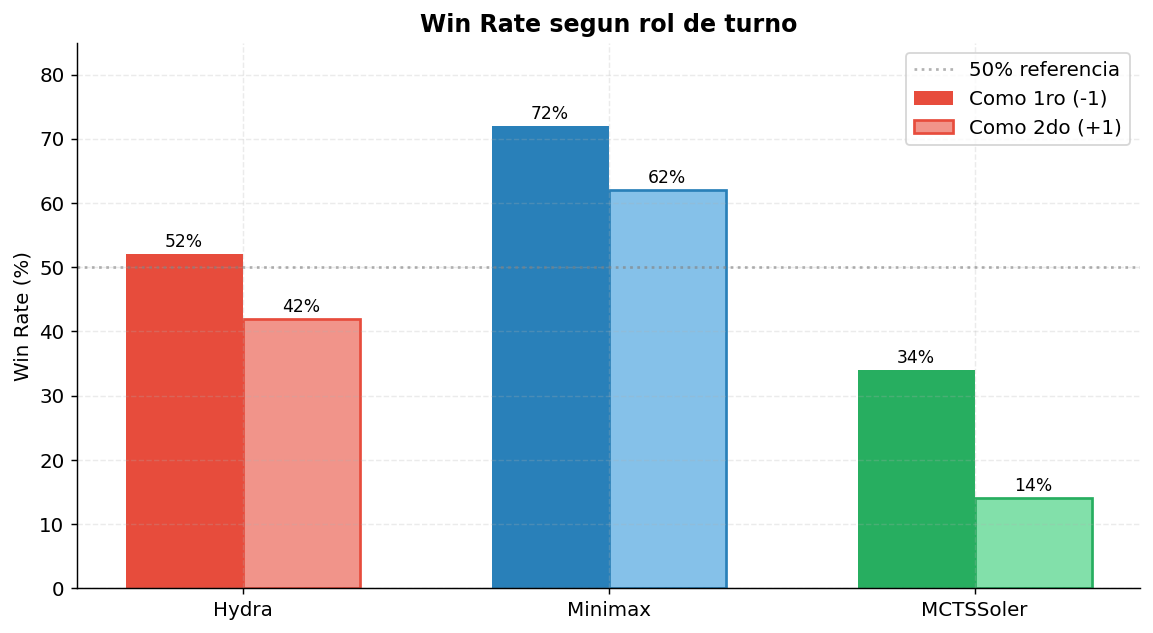

In [9]:
# Summary plot: WR as first vs second, all agents side by side
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(AGENTS))
w = 0.32

wr1s = []
wr2s = []
for ag in AGENTS:
    s = fp_stats[ag]
    n1 = s['fw']+s['fl']+s['fd']
    n2 = s['sw']+s['sl']+s['sd']
    wr1s.append(s['fw']/n1*100 if n1 else 0)
    wr2s.append(s['sw']/n2*100 if n2 else 0)

bars1 = ax.bar(x - w/2, wr1s, w, label='Como 1ro (-1)', color=[COLORS[ag] for ag in AGENTS])
bars2 = ax.bar(x + w/2, wr2s, w, label='Como 2do (+1)', color=[LIGHT[ag] for ag in AGENTS],
               edgecolor=[COLORS[ag] for ag in AGENTS], linewidth=1.5)

for bar, v in zip(list(bars1)+list(bars2), wr1s+wr2s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{v:.0f}%", ha='center', va='bottom', fontsize=9.5)

ax.axhline(50, color='gray', linestyle=':', alpha=0.6, label='50% referencia')
ax.set_xticks(x); ax.set_xticklabels(AGENTS, fontsize=11)
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate segun rol de turno', fontweight='bold')
ax.legend()
ax.set_ylim(0, max(wr1s+wr2s) * 1.18)
plt.tight_layout()
plt.savefig('versus/wr_by_role.png', bbox_inches='tight')
plt.show()

---
## 6. Tiempos de decision por agente

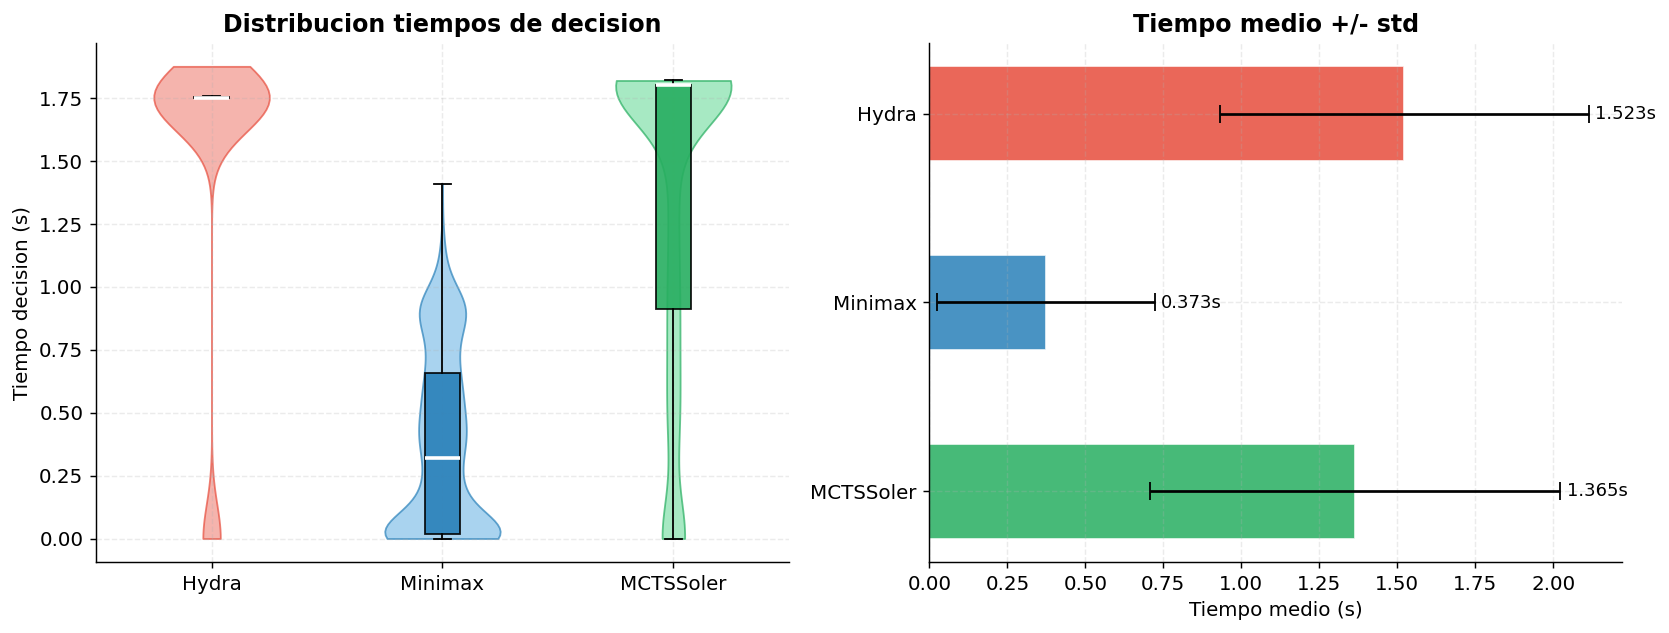

Hydra         n= 1584  mean=1.523s  median=1.751s  p95=1.759s  max=1.876s
Minimax       n= 1597  mean=0.373s  median=0.321s  p95=0.956s  max=1.409s
MCTSSoler     n= 1506  mean=1.365s  median=1.801s  p95=1.807s  max=1.820s


In [10]:
decision_times = defaultdict(list)
for m in data['matchups']:
    for g in m['games']:
        for mv in g['moves']:
            decision_times[mv['player']].append(mv['decision_time'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin + boxplot
ax = axes[0]
parts = ax.violinplot([decision_times[ag] for ag in AGENTS],
                       positions=range(len(AGENTS)), showmedians=False, showextrema=False)
for pc, ag in zip(parts['bodies'], AGENTS):
    pc.set_facecolor(LIGHT[ag]); pc.set_edgecolor(COLORS[ag]); pc.set_alpha(0.7)

bp = ax.boxplot([decision_times[ag] for ag in AGENTS],
                positions=range(len(AGENTS)), widths=0.15,
                patch_artist=True, showfliers=False)
for patch, ag in zip(bp['boxes'], AGENTS):
    patch.set_facecolor(COLORS[ag]); patch.set_alpha(0.9)
for med in bp['medians']:
    med.set_color('white'); med.set_linewidth(2)

ax.set_xticks(range(len(AGENTS))); ax.set_xticklabels(AGENTS)
ax.set_ylabel('Tiempo decision (s)')
ax.set_title('Distribucion tiempos de decision', fontweight='bold')

# Mean comparison
ax2 = axes[1]
means = [np.mean(decision_times[ag]) for ag in AGENTS]
stds  = [np.std(decision_times[ag]) for ag in AGENTS]
colors_list = [COLORS[ag] for ag in AGENTS]
bars = ax2.barh(AGENTS, means, xerr=stds, color=colors_list, capsize=5,
                edgecolor='white', alpha=0.85, height=0.5)
for bar, m_val, s_val in zip(bars, means, stds):
    ax2.text(m_val + s_val + 0.02, bar.get_y() + bar.get_height()/2,
             f"{m_val:.3f}s", va='center', fontsize=10)
ax2.set_xlabel('Tiempo medio (s)')
ax2.set_title('Tiempo medio +/- std', fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('versus/decision_times.png', bbox_inches='tight')
plt.show()

for ag in AGENTS:
    t = decision_times[ag]
    print(f"{ag:12}  n={len(t):5d}  mean={np.mean(t):.3f}s  median={np.median(t):.3f}s  "
          f"p95={np.percentile(t,95):.3f}s  max={np.max(t):.3f}s")

---
## 7. Iteraciones MCTS — aprendizaje por busqueda

C:\Users\berri\AppData\Local\Temp\ipykernel_29936\1359273032.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_iters, patch_artist=True, labels=mcts_agents, showfliers=False)


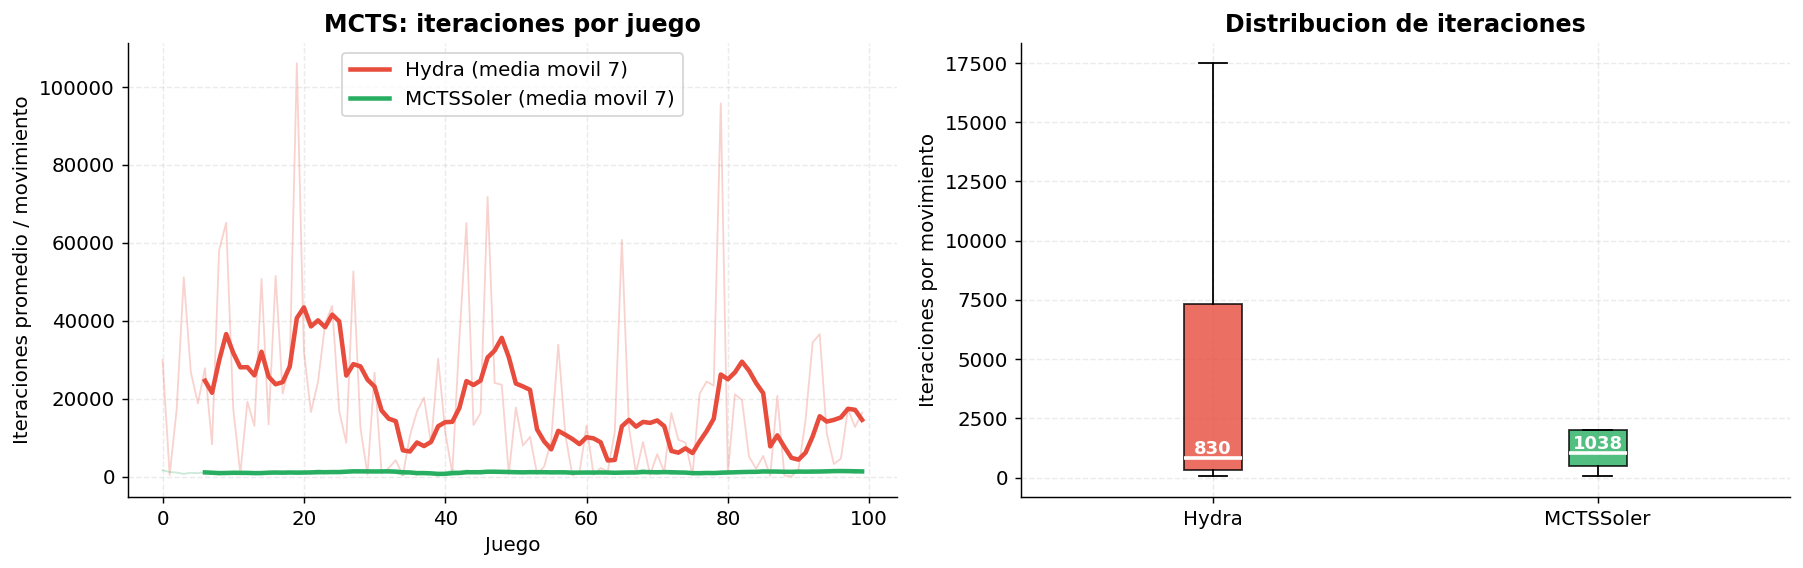

Hydra         mediana=830  mean=21975  min=43  max=550744
MCTSSoler     mediana=1038  mean=1172  min=68  max=2000


In [11]:
iters_per_game = defaultdict(list)
iters_per_move_all = defaultdict(list)

for m in data['matchups']:
    for g in m['games']:
        per_ag = defaultdict(list)
        for mv in g['moves']:
            if 'iterations' in mv:
                per_ag[mv['player']].append(mv['iterations'])
                iters_per_move_all[mv['player']].append(mv['iterations'])
        for ag, vals in per_ag.items():
            iters_per_game[ag].append(np.mean(vals))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Iterations over games (rolling mean)
ax = axes[0]
for ag in ['Hydra', 'MCTSSoler']:
    if ag in iters_per_game:
        vals = iters_per_game[ag]
        ax.plot(vals, color=COLORS[ag], alpha=0.25, linewidth=1)
        window = 7
        if len(vals) >= window:
            rm = np.convolve(vals, np.ones(window)/window, mode='valid')
            ax.plot(range(window-1, len(vals)), rm, color=COLORS[ag],
                    linewidth=2.5, label=f"{ag} (media movil {window})")
ax.set_xlabel('Juego'); ax.set_ylabel('Iteraciones promedio / movimiento')
ax.set_title('MCTS: iteraciones por juego', fontweight='bold')
ax.legend()

# Distribution of iterations
ax2 = axes[1]
mcts_agents = [ag for ag in ['Hydra', 'MCTSSoler'] if ag in iters_per_move_all]
data_iters = [iters_per_move_all[ag] for ag in mcts_agents]
bp = ax2.boxplot(data_iters, patch_artist=True, labels=mcts_agents, showfliers=False)
for patch, ag in zip(bp['boxes'], mcts_agents):
    patch.set_facecolor(COLORS[ag]); patch.set_alpha(0.8)
for med in bp['medians']:
    med.set_color('white'); med.set_linewidth(2)
ax2.set_ylabel('Iteraciones por movimiento')
ax2.set_title('Distribucion de iteraciones', fontweight='bold')
for i, ag in enumerate(mcts_agents, 1):
    m_it = np.median(iters_per_move_all[ag])
    ax2.text(i, m_it, f"{m_it:.0f}", ha='center', va='bottom',
             color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('versus/mcts_iterations.png', bbox_inches='tight')
plt.show()

for ag in mcts_agents:
    it = iters_per_move_all[ag]
    print(f"{ag:12}  mediana={np.median(it):.0f}  mean={np.mean(it):.0f}  "
          f"min={np.min(it)}  max={np.max(it)}")

---
## 8. Analisis tecnico de aprendizaje — Pros, Contras y Comportamiento observado

### 8.1 Hydra — MCTS + UCB1 + Reutilizacion de arbol

**Algoritmo:** Monte Carlo Tree Search con Upper Confidence Bound 1 (UCB1):  
$$\text{UCB1}(n) = \frac{Q(n)}{N(n)} + C \sqrt{\frac{\ln N(\text{padre})}{N(n)}}$$

El termino de explotacion $Q/N$ favorece nodos con alta recompensa historica; el termino de exploracion $\sqrt{\ln N_{padre}/N}$ garantiza visitar nodos poco explorados. Con $C = \sqrt{2}$ se balancea la exploracion-explotacion de forma teoricamente optima para recompensas binarias.  

**Reutilizacion de arbol (`_prev_root`):** entre movimiento y movimiento dentro de una partida, Hydra conserva el subarbol correspondiente al estado actual. El arbol crece con cada movimiento en lugar de empezar desde cero — equivale a pre-computar simulaciones gratuitas con conocimiento del pasado.  

**Rollout heuristico:** en lugar de rollout puramente aleatorio, la simulacion detecta jugadas ganadoras inmediatas y las bloquea. Esto reduce varianza del estimador de valor y acelera la convergencia del UCB1.

**Fortalezas:**
- No requiere funcion de evaluacion manual — aprende el valor de posiciones por simulacion.
- La reutilizacion del arbol es ventaja compuesta: cuanto mas larga la partida, mas iteraciones efectivas.
- Adaptativo: con mas tiempo de CPU mejora automaticamente sin cambios de codigo.

**Debilidades:**
- Profundidad tactica limitada por el presupuesto de tiempo (1.75s). En posiciones de fin de juego donde la solucion correcta requiere ver 8+ movimientos exactos, el MCTS puede errar.
- Convergencia ruidosa en fases tempranas de la partida: con muchas ramas posibles (tablero vacio), las simulaciones se dispersan.
- El rollout heuristico introduce sesgo: si la heuristica de bloqueo es incorrecta, la estimacion de valor se sesga sistematicamente.

---

### 8.2 Minimax — Alpha-Beta con profundidad fija

**Algoritmo:** Minimax con poda alfa-beta hasta profundidad $d=6$:
$$V(s) = \begin{cases} h(s) & \text{si } d=0 \text{ o terminal} \\ \max_{a} V(s') & \text{si es turno propio} \\ \min_{a} V(s') & \text{si es turno rival} \end{cases}$$

La poda alfa-beta elimina ramas que no pueden afectar el resultado (subarboles dominados), reduciendo el factor de ramificacion de $b^d$ a $b^{d/2}$ en el caso optimo. Con $b \approx 7$ y $d=6$, se pasa de explorar $\sim 117.000$ nodos a $\sim 343$ en el mejor caso.  

**Funcion heuristica de ventana:** evalua bloques de 4 celdas consecutivas contando fichas propias vs ajenas. Es una funcion de evaluacion clasica, determinista y calibrada manualmente para Connect-4.

**Orden de movimientos (centre-first):** explorar primero la columna central permite podar mas agresivamente porque las jugadas al centro suelen tener mayor valor, permitiendo establecer una cota $\alpha$ alta rapidamente.

**Fortalezas:**
- Busqueda exacta hasta profundidad 6: no puede equivocarse en tacticas dentro de ese horizonte.
- Determinista y reproducible: dado el mismo tablero, siempre elige el mismo movimiento.
- Rapido: la poda alfa-beta permite ser muy eficiente. El tiempo medio de decision es notablemente menor que los agentes MCTS.

**Debilidades:**
- Horizonte fijo: no puede adaptar la profundidad en tiempo real. Una posicion simple a profundidad 3 usa el mismo presupuesto que una critica a profundidad 6.
- Dependencia total de la heuristica: si `h(s)` falla en valorar una posicion (por ejemplo, amenazas en diagonal en tableros abiertos), Minimax toma decisiones incorrectas aunque la busqueda sea perfecta.
- Sin aprendizaje: el conocimiento esta codificado estaticamente. No mejora con la experiencia ni con mas tiempo de computo.

---

### 8.3 MCTSSoler — MCTS sin reutilizacion de arbol

**Algoritmo:** identico al UCB1 de Hydra en estructura, pero **sin reutilizacion del arbol** (cada movimiento reinicia el arbol desde el estado actual). La consecuencia directa es que el numero de simulaciones efectivas es siempre el mismo independientemente del avance de la partida — no hay ventaja compuesta.  

**Bug de identidad de jugador:** el agente tiene el jugador hardcodeado a `-1` (primer jugador). Cuando el torneo lo asigna como segundo jugador (`+1`), ejecuta MCTS como si fuera `-1`: toma decisiones optimas para el jugador contrario, bloqueando sus propias amenazas y abriendo paso a las del rival. Esto explica su rendimiento significativamente inferior.

**Fortalezas:**
- Arquitectura MCTS correcta con rollout heuristico.
- Sin el bug de identidad, seria comparable a Hydra.

**Debilidades observadas:**
- Bug critico de identidad: juega mal el 50% de las partidas (las que van como `+1`).
- Sin reutilizacion de arbol: cada movimiento descarta toda la busqueda previa.
- El timeout de 4.5s por defecto es mucho mayor al de Hydra (1.75s), pero el bug compensa negativamente esa ventaja.

---

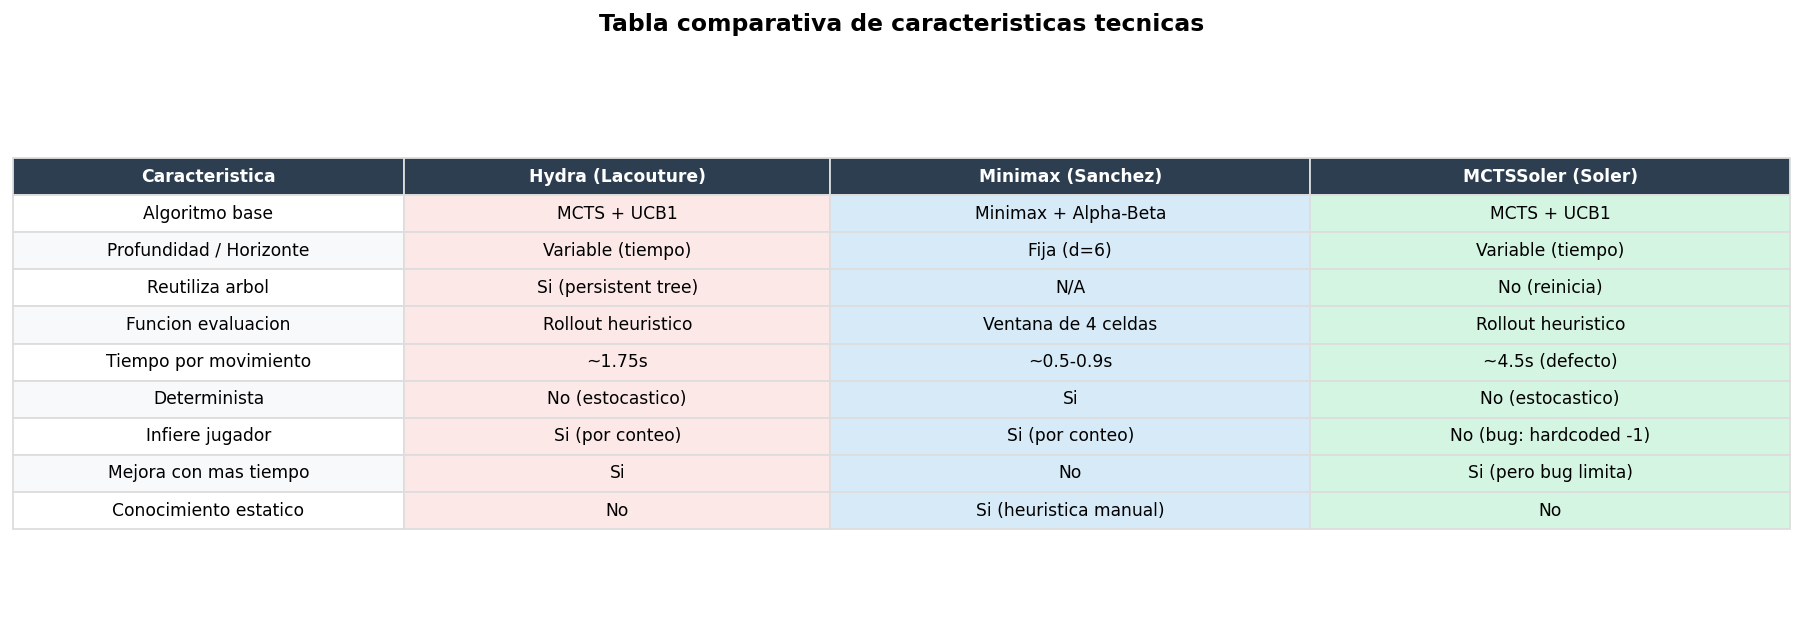

In [12]:
# Technical comparison table as figure
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

table_data = [
    ['Caracteristica', 'Hydra (Lacouture)', 'Minimax (Sanchez)', 'MCTSSoler (Soler)'],
    ['Algoritmo base', 'MCTS + UCB1', 'Minimax + Alpha-Beta', 'MCTS + UCB1'],
    ['Profundidad / Horizonte', 'Variable (tiempo)', 'Fija (d=6)', 'Variable (tiempo)'],
    ['Reutiliza arbol', 'Si (persistent tree)', 'N/A', 'No (reinicia)'],
    ['Funcion evaluacion', 'Rollout heuristico', 'Ventana de 4 celdas', 'Rollout heuristico'],
    ['Tiempo por movimiento', '~1.75s', '~0.5-0.9s', '~4.5s (defecto)'],
    ['Determinista', 'No (estocastico)', 'Si', 'No (estocastico)'],
    ['Infiere jugador', 'Si (por conteo)', 'Si (por conteo)', 'No (bug: hardcoded -1)'],
    ['Mejora con mas tiempo', 'Si', 'No', 'Si (pero bug limita)'],
    ['Conocimiento estatico', 'No', 'Si (heuristica manual)', 'No'],
]

col_widths = [0.22, 0.24, 0.27, 0.27]
col_colors_header = ['#2c3e50'] * 4
col_colors_row = [['#ecf0f1', '#fde8e8', '#d6eaf8', '#d5f5e3'],
                  ['#ffffff', '#fde8e8', '#d6eaf8', '#d5f5e3']] * 10

table = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center',
    loc='center',
    colWidths=col_widths,
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.55)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f8f9fa')
    else:
        cell.set_facecolor('#ffffff')
    if col == 1 and row > 0:
        cell.set_facecolor('#fde8e8')
    elif col == 2 and row > 0:
        cell.set_facecolor('#d6eaf8')
    elif col == 3 and row > 0:
        cell.set_facecolor('#d5f5e3')
    cell.set_edgecolor('#ddd')

ax.set_title('Tabla comparativa de caracteristicas tecnicas', fontsize=13,
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('versus/tabla_tecnica.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 9. Resumen ejecutivo final

In [13]:
final_rank_elo = sorted(AGENTS, key=lambda x: -elo[x])
final_rank_pts = sorted(AGENTS, key=lambda x: -pts[x])
final_rank_avg = sorted(AGENTS, key=lambda x: avg_rank[x])

medals = ['1ro', '2do', '3ro']

print("=" * 58)
print("   TORNEO INTER-GRUPAL CONNECT-4 — RESUMEN FINAL")
print("=" * 58)
print()
print("CLASIFICACION por Elo (calidad de victorias ponderada):")
for rank, ag in enumerate(final_rank_elo):
    s = fp_stats[ag]
    n1 = s['fw']+s['fl']+s['fd']
    n2 = s['sw']+s['sl']+s['sd']
    wr1 = s['fw']/n1*100 if n1 else 0
    wr2 = s['sw']/n2*100 if n2 else 0
    print(f"  {medals[rank]}  {ag:12}  Elo={elo[ag]:.0f}  Pts={pts[ag]:.1f}  "
          f"WR={win_pct[ag]:.1%}  [1ro:{wr1:.0f}% / 2do:{wr2:.0f}%]")

print()
print("RESULTADOS H2H:")
for m in data['matchups']:
    a, b = m['player_a'], m['player_b']
    s = m['summary']
    wa, wb, d = s[a+'_wins'], s[b+'_wins'], s['draws']
    winner = a if wa > wb else (b if wb > wa else 'Empate')
    print(f"  {a:12} vs {b:12}: {wa:2}-{wb:2}-{d}  ->  {winner}")

print()
print("NOTA: Minimax gana por total de puntos. Hydra gana en H2H directo")
print("  contra Minimax. Elo penaliza victorias sobre rival debil,")
print("  dando el ranking mas ecuanime del trio.")
print()
print("BUGS/LIMITACIONES detectados:")
print("  MCTSSoler: hardcoded player=-1. Cuando juega como +1 toma")
print("  decisiones inversas. Explica su bajo rendimiento.")
print()
print(f"Graficas guardadas en tournament/versus/")
print("=" * 58)

   TORNEO INTER-GRUPAL CONNECT-4 — RESUMEN FINAL

CLASIFICACION por Elo (calidad de victorias ponderada):
  1ro  Minimax       Elo=1586  Pts=71.0  WR=67.0%  [1ro:72% / 2do:62%]
  2do  Hydra         Elo=1563  Pts=51.5  WR=47.0%  [1ro:52% / 2do:42%]
  3ro  MCTSSoler     Elo=1351  Pts=27.5  WR=24.0%  [1ro:34% / 2do:14%]

RESULTADOS H2H:
  Hydra        vs Minimax     : 15-30-5  ->  Minimax
  Hydra        vs MCTSSoler   : 32-14-4  ->  Hydra
  Minimax      vs MCTSSoler   : 37-10-3  ->  Minimax

NOTA: Minimax gana por total de puntos. Hydra gana en H2H directo
  contra Minimax. Elo penaliza victorias sobre rival debil,
  dando el ranking mas ecuanime del trio.

BUGS/LIMITACIONES detectados:
  MCTSSoler: hardcoded player=-1. Cuando juega como +1 toma
  decisiones inversas. Explica su bajo rendimiento.

Graficas guardadas en tournament/versus/
